In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [5]:
# 1. Load the dataset
file_path = "E:/Data Science/14-Naive Bayes/Disaster_tweets_NB.csv"  # Replace with your file path
tweets_data = pd.read_csv(file_path)
tweets_data


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
...,...,...,...,...,...
7608,10869,NaN,NaN,Two giant cranes holding a bridge collapse int...,1
7609,10870,NaN,NaN,@aria_ahrary @TheTawniest The out of control w...,1
7610,10871,NaN,NaN,M1.94 [01:04 UTC]?5km S of Volcano Hawaii. htt...,1
7611,10872,NaN,NaN,Police investigating after an e-bike collided ...,1


In [7]:
# 2. Data Dictionary
print("Dataset Columns:\n", tweets_data.columns)
print("\nData Types:\n", tweets_data.dtypes)
print("\nMissing Values:\n", tweets_data.isna().sum())
print("\nSample Data:\n", tweets_data.head())

Dataset Columns:
 Index(['id', 'keyword', 'location', 'text', 'target'], dtype='object')

Data Types:
 id           int64
keyword     object
location    object
text        object
target       int64
dtype: object

Missing Values:
 id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

Sample Data:
    id keyword location                                               text  \
0   1     NaN      NaN  Our Deeds are the Reason of this #earthquake M...   
1   4     NaN      NaN             Forest fire near La Ronge Sask. Canada   
2   5     NaN      NaN  All residents asked to 'shelter in place' are ...   
3   6     NaN      NaN  13,000 people receive #wildfires evacuation or...   
4   7     NaN      NaN  Just got sent this photo from Ruby #Alaska as ...   

   target  
0       1  
1       1  
2       1  
3       1  
4       1  


In [9]:
# 3. Data Pre-processing
# Filling missing values (if any) in 'text' column with an empty string
if 'text' in tweets_data.columns:
    tweets_data['text'] = tweets_data['text'].fillna("")


In [11]:
# Dropping rows with missing labels (if any)
tweets_data = tweets_data.dropna(subset=['target'])


In [13]:
# Splitting data into features (X) and target (y)
X = tweets_data['text']
y = tweets_data['target']

In [15]:
vectorizer = CountVectorizer(stop_words='english', max_features=5000)
X_vectorized = vectorizer.fit_transform(X)


In [17]:
# 5. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42)


In [19]:
# 6. Model Building and Evaluation
# Initialize and train the Multinomial Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [21]:
# Predictions on the test dataset
y_pred = model.predict(X_test)


In [23]:
# Evaluate the model
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy Score:", accuracy_score(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.85      0.82       874
           1       0.77      0.70      0.74       649

    accuracy                           0.79      1523
   macro avg       0.78      0.78      0.78      1523
weighted avg       0.79      0.79      0.78      1523


Confusion Matrix:
 [[740 134]
 [192 457]]

Accuracy Score: 0.7859487852921865


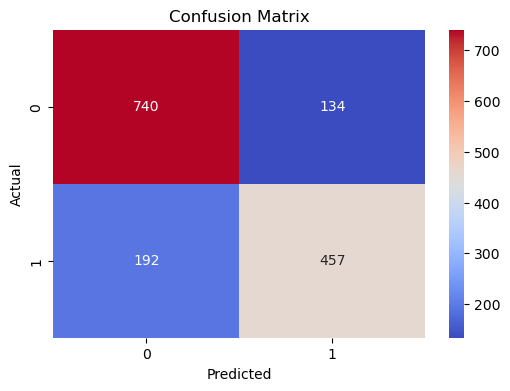

In [25]:
# Visualizing the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="coolwarm")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Benefits to the Client:
1. This solution helps classify tweets as real or fake, enabling better disaster management.
2. Automating tweet classification improves efficiency and reduces manual workload.
3. The insights from real tweets can be used for timely interventions and planning.